# Critical Heat Flux — Variational Feedforward Neural Network (vFNN)

This notebook applies a **variational feedforward neural network** to the CHF dataset. A vFNN replaces the deterministic output layer with a Bayesian `DenseReparameterization` layer from TensorFlow Probability. At every forward pass the layer samples its weights from a learned posterior distribution $\mathcal{N}(\mu_w,\, \text{softplus}(\rho_w))$, so repeated calls to the same input produce different predictions. The spread of those predictions is a direct measure of **epistemic (model) uncertainty**.

The training objective is:
$$\mathcal{L} = \text{MSE}(y, \hat{y}) + \beta\, D_{\text{KL}}(q(w) \,\|\, p(w))$$

where the KL term is added automatically by the TFP layer and $\beta$ is handled internally by the Keras loss summation.

**Inputs / Outputs**: same as the standard CHF benchmark — six hydraulic parameters → CHF (kW m⁻²). See `chf.ipynb` for the full dataset description.

In [8]:
import time
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from pyMAISE.datasets import load_chf
from pyMAISE.preprocessing import correlation_matrix, scale_data
import pyMAISE as mai

plt.rcParams.update({"font.size": 12, "legend.fontsize": 11, "figure.figsize": (8, 8)})

## Initialization and Preprocessing

In [9]:
global_settings = mai.init(
    problem_type=mai.ProblemType.REGRESSION,
    verbosity=1,
    num_configs_saved=5,
    cuda_visible_devices="-1",  # CPU only
)

train_data, xtrain, ytrain, test_data, xtest, ytest = load_chf()

Reading data from /home/orlando/projects/pyMAISE/pyMAISE/datasets/chf_train_synth.csv
Reading data from /home/orlando/projects/pyMAISE/pyMAISE/datasets/chf_test_synth.csv


In [10]:
xtrain

<xarray.DataArray (index: 2000, variable: 6)> Size: 96kB
array([[1.01591633e-02, 2.98755621e+00, 1.99910352e+04, 5.20754066e+02,
        2.60238993e+02, 3.36618827e-01],
       [9.61641659e-03, 5.48464942e+00, 7.07735164e+03, 2.74115374e+03,
        2.31174290e+02, 4.12976136e-01],
       [7.58601972e-03, 7.66842472e-01, 1.42533415e+04, 4.03670025e+03,
        2.92868636e+02, 2.48984031e-02],
       ...,
       [8.05556451e-03, 1.03945144e+00, 6.74277013e+03, 2.03124398e+03,
        1.31730956e+02, 1.67113569e-01],
       [1.14979333e-02, 1.78439632e+00, 6.83238523e+03, 1.94423864e+03,
        2.66335292e+02, 3.57005646e-01],
       [7.48060708e-03, 2.97318942e+00, 1.39846734e+04, 4.10568657e+03,
        3.22802524e+02, 2.77580848e-01]], shape=(2000, 6))
Coordinates:
  * index     (index) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
  * variable  (variable) object 48B 'D (m)' 'L (m)' ... 'Tin (C)' 'Xe (-)'

In [11]:
ytrain

<xarray.DataArray (index: 2000, variable: 1)> Size: 16kB
array([[ 377.05549841],
       [ 956.92913687],
       [3091.19358014],
       ...,
       [3725.37959666],
       [2066.25518823],
       [ 969.10507166]], shape=(2000, 1))
Coordinates:
  * index     (index) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
  * variable  (variable) object 8B 'CHF (kW m-2)'

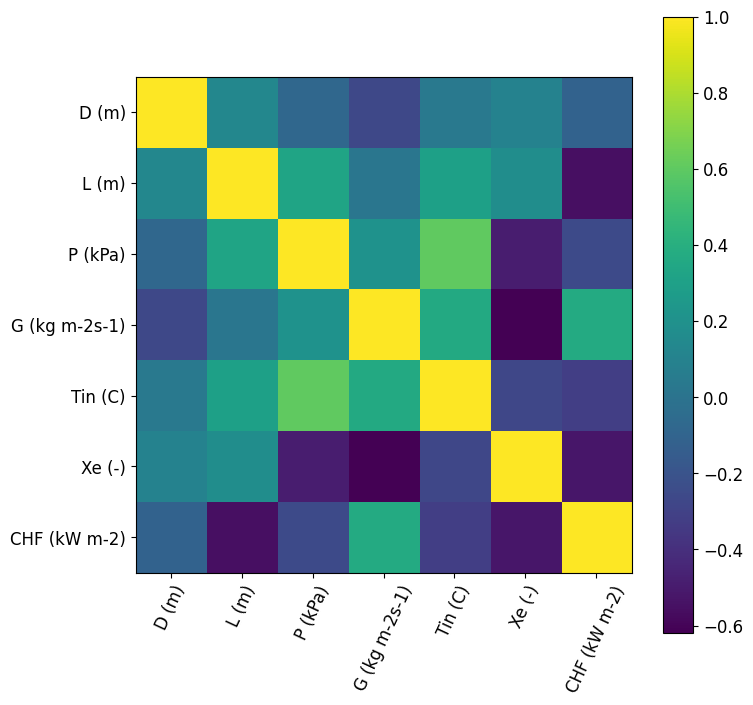

In [12]:
correlation_matrix(xr.concat([train_data, test_data], dim="samples"))
plt.show()

In [13]:
xtrain, xtest, xscaler = scale_data(xtrain, xtest, scaler=MinMaxScaler())
ytrain, ytest, yscaler = scale_data(ytrain, ytest, scaler=MinMaxScaler())

## Model Definition

The vFNN architecture is:

```
Input (6) → Dense×[1–3] (relu/tanh, optional Dropout) → DenseReparameterization (1, linear)
```

The `Variational_output` key triggers the `VariationalLayer` wrapper around TFP's `DenseReparameterization`. All other layers are standard Keras `Dense` layers.

We tune:
- number of hidden layers (1–3)
- hidden units (50–300)
- activation function (`relu` or `tanh`)
- whether to include a `Dropout` sublayer

In [14]:
structural = {
    "Dense_hidden": {
        "num_layers": mai.Int(min_value=2, max_value=3),
        "units": mai.Int(min_value=150, max_value=300),
        "activation": "relu",
        "kernel_initializer": "glorot_uniform",
        "sublayer": mai.Choice(["Dropout_hidden", "None"]),
        "Dropout_hidden": {
            "rate": mai.Float(min_value=0.2, max_value=0.5),
        },
    },
    "Variational_output": {
        "units": ytrain.shape[-1],
        "activation": "linear",
        "kl_weight": 1.0 / ytrain.shape[0],  # scale KL by 1/n_train for proper ELBO
    },
}

model_settings = {
    "models": ["vFNN"],
    "vFNN": {
        "structural_params": structural,
        "optimizer": "Adam",
        "Adam": {
            "learning_rate": 0.001,
        },
        "compile_params": {
            "loss": "mean_squared_error",
            "metrics": ["mean_squared_error"],
        },
        "fitting_params": {
            "batch_size": 64,
            "epochs": 50,
            "validation_split": 0.15,
        },
    },
}

tuner = mai.Tuner(xtrain, ytrain, model_settings=model_settings)

## Hyperparameter Tuning

We use Bayesian search with 30 trials and 5-fold cross-validation. Bayesian optimisation is a good fit here because each vFNN trial is relatively expensive (KL divergence adds overhead) and the search space is continuous.

In [15]:
start = time.time()
bayesian_search_configs = tuner.nn_bayesian_search(
    objective="r2_score",
    max_trials=12,
    cv=5,
)
print(f"Hyperparameter tuning took {(time.time() - start) / 60:.1f} minutes.")

Trial 12 Complete [00h 00m 20s]
r2_score: 0.8367146604840737

Best r2_score So Far: 0.9072584302408113
Total elapsed time: 00h 04m 02s

Top Configurations

-- vFNN | Training Time: 00:04:02
Dense_hidden_num_layers: 2
Dense_hidden_0_units: 278
Dense_hidden_0_sublayer: Dropout_hidden
Dense_hidden_0_sublayer_Dropout_hidden_0_rate: 0.4437631879483859
Dense_hidden_1_units: 223
Dense_hidden_1_sublayer: None
Dense_hidden_1_sublayer_Dropout_hidden_0_rate: 0.49847829842056934
Dense_hidden_2_units: 249
Dense_hidden_2_sublayer: Dropout_hidden
Dense_hidden_2_sublayer_Dropout_hidden_0_rate: 0.20420138770924745
Hyperparameter tuning took 4.0 minutes.


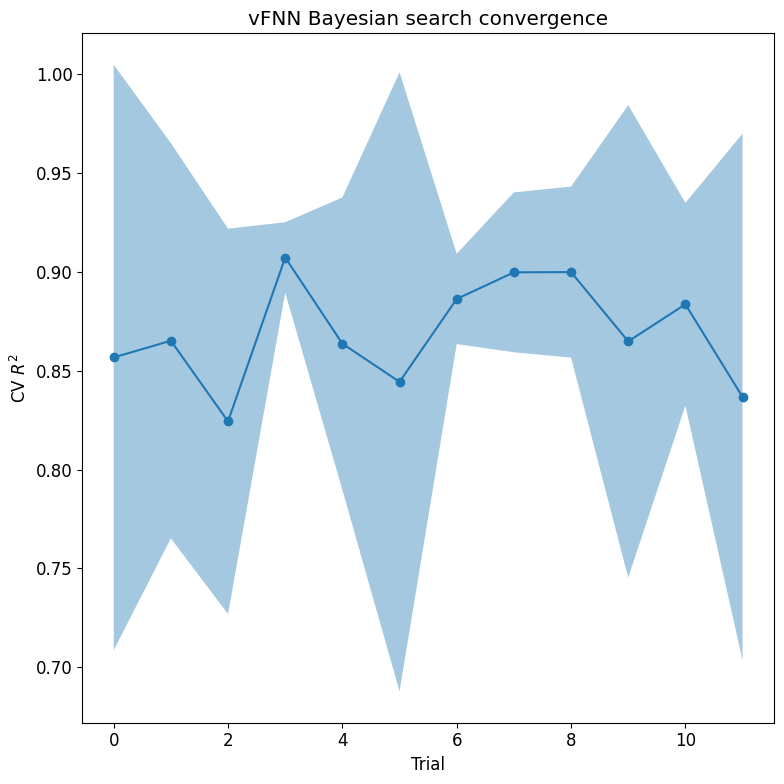

In [16]:
ax = tuner.convergence_plot(model_types="vFNN")
ax.set_xlabel("Trial")
ax.set_ylabel("CV $R^2$")
ax.set_title("vFNN Bayesian search convergence")
plt.tight_layout()
plt.show()

## Model Postprocessing

We pass the top 5 configurations to `PostProcessor`, bumping epochs to 150 for a more fully-trained model. The `n_mc_samples=1000` argument tells pyMAISE to run 1,000 stochastic forward passes when predicting, storing the full sample distribution for the uncertainty plots below.

In [17]:
postprocessor = mai.PostProcessor(
    data=(xtrain, xtest, ytrain, ytest),
    model_configs=[bayesian_search_configs],
    new_model_settings={
        "vFNN": {"fitting_params": {"epochs": 150}},
    },
    yscaler=yscaler,
    n_mc_samples=1000,
)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/150
27/27 [==============================] - 1s 6ms/step - loss: 0.3255 - mean_squared_error: 0.0436 - val_loss: 0.2918 - val_mean_squared_error: 0.0110
Epoch 2/150
27/27 [==============================] - 0s 2ms/step - loss: 0.2923 - mean_squared_error: 0.0124 - val_loss: 0.2852 - val_mean_squared_error: 0.0066
Epoch 3/150
27/27 [==============================] - 0s 2ms/step - loss: 0.2874 - mean_squared_error: 0.0099 - val_loss: 0.2816 - val_mean_squared_error: 0.0052
Epoch 4/150
27/27 [==============================] - 0s 2ms/step - loss: 0.2822 - mean_squared_error: 0.0070 - val_loss: 0.2780 - val_mean_squared_error: 0.0040
Epoch 5/150
27/27 [==============================] - 0s 2ms/step - loss: 0.2789 - mean_squared_error: 0.0061 - val_loss: 0.2742 - val_mean_squared_error: 0.0027
Epoch 6/150
27/27 [==============================] - 0s 2ms/step - loss: 0.2752 - mean_squared_error: 0.0049 - val_loss: 0.2717 - val_mean_squared_error: 0.0027
Epoch 7/150
27/27 [===============

In [18]:
postprocessor.metrics().drop("Parameter Configurations", axis=1)

,Model Types,Train R2,Train MAE,Train MAPE,Train RMSE,Train RMSPE,Test R2,Test MAE,Test MAPE,Test RMSE,Test RMSPE
2,vFNN,0.954975,248.583484,30.048033,308.442064,54.516875,0.947447,248.209874,26.351775,305.379632,44.248158
0,vFNN,0.939291,255.754872,31.850534,358.157057,65.085858,0.929092,253.556245,27.419812,354.722889,50.827727
1,vFNN,0.934676,292.565155,40.200265,371.521126,72.295015,0.920586,297.122245,36.017294,375.396684,61.584825
3,vFNN,0.928995,266.984672,27.836457,387.340283,56.935995,0.914690,267.684971,23.758480,389.082852,43.137073
4,vFNN,0.916851,323.175779,38.694464,419.157700,68.586585,0.900725,316.655456,34.470444,419.720819,58.950510


In [19]:
postprocessor.print_model(model_type="vFNN")

Model Type: vFNN
  Structural Hyperparameters
    Layer: Dense_hidden_0
      units: 227
      sublayer: None
    Layer: Dense_hidden_1
      units: 154
      sublayer: None
    Layer: Variational_output_0
  Compile/Fitting Hyperparameters
Model: "vFNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Dense_hidden_0 (Dense)      (None, 227)               1589      
                                                                 
 Dense_hidden_1 (Dense)      (None, 154)               35112     
                                                                 
 Variational_output_0 (Dens  (None, 1)                 309       
 eReparameterization)                                            
                                                                 
Total params: 37010 (144.57 KB)
Trainable params: 37010 (144.57 KB)
Non-trainable params: 0 (0.00 Byte)
________________________________________________

## Uncertainty-Aware Parity Plot

`variational_parity_plot` overlays shaded confidence-interval bands on the standard parity plot:

- **light blue (α=0.15)** — 95 % predictive interval (mean ± 1.96 σ)
- **medium blue (α=0.30)** — 90 % predictive interval (mean ± 1.645 σ)
- **red dots** — mean prediction for each test sample
- **dashed diagonal** — perfect prediction

The bands are drawn over true values sorted in ascending order so they render without crossing. The scatter is unsorted (original test-set order).

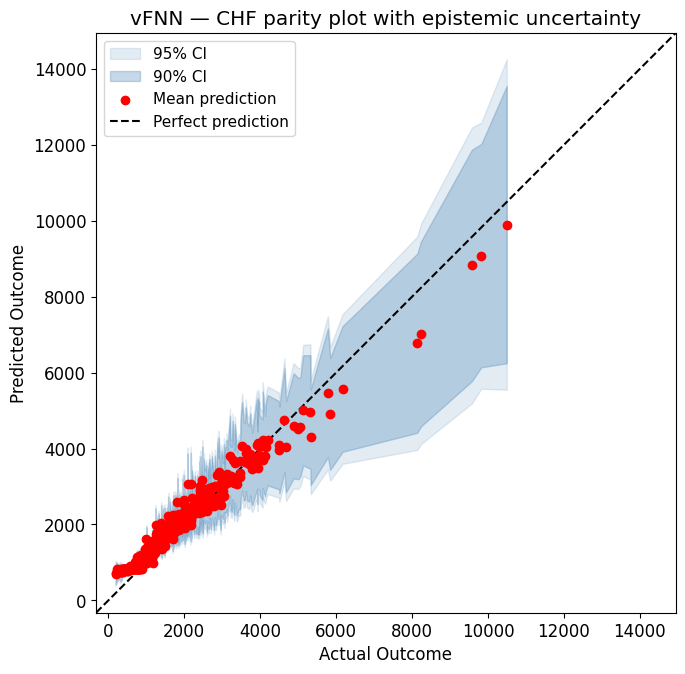

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))
ax = postprocessor.variational_parity_plot(ax=ax, model_type="vFNN")
ax.set_title("vFNN — CHF parity plot with epistemic uncertainty")
plt.tight_layout()
plt.show()

## Learning Curve

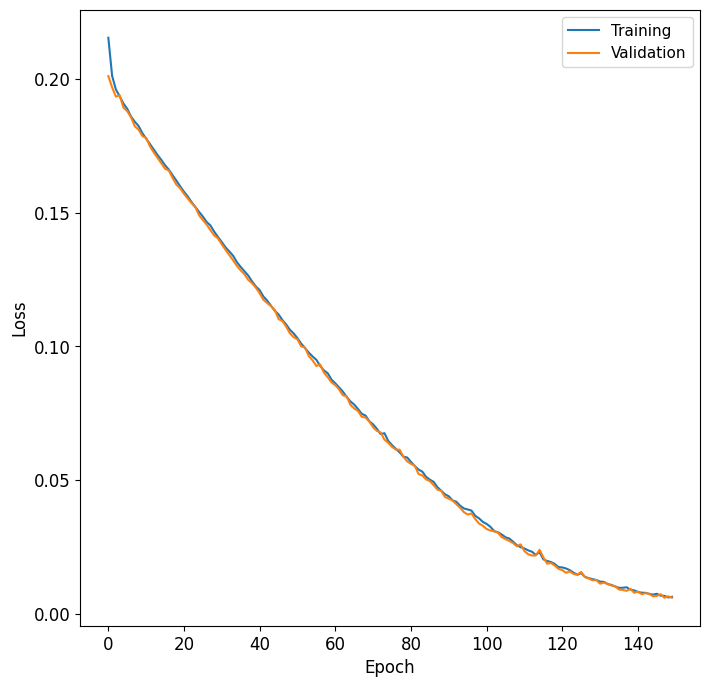

In [21]:
postprocessor.nn_learning_plot(model_type="vFNN")
plt.show()

## Epistemic Uncertainty vs. True CHF

The MC sample standard deviation is a direct estimate of the model's epistemic uncertainty for each test point. Plotting it against the true CHF value reveals whether the model is systematically more uncertain in particular regions of the output space — a common pattern with deterministic simulation data, where the training density is uneven.

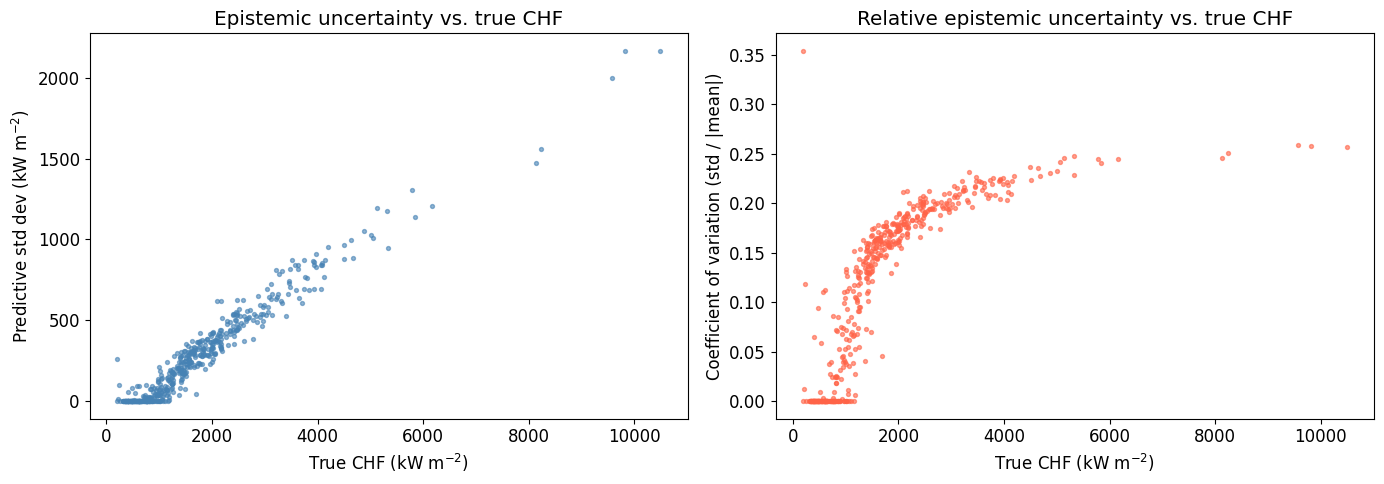

In [22]:
# Best-model MC samples are already inverse-scaled: (n_mc, n_test, 1)
mc_samples = postprocessor._models["MC Samples"][0]

true_vals = yscaler.inverse_transform(ytest.values).squeeze()  # (n_test,)
stds = mc_samples.std(axis=0).squeeze()                        # (n_test,)
means = mc_samples.mean(axis=0).squeeze()                      # (n_test,)

sort_idx = np.argsort(true_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: std dev vs. true CHF
axes[0].scatter(true_vals[sort_idx], stds[sort_idx], s=8, alpha=0.6, c="steelblue")
axes[0].set_xlabel("True CHF (kW m$^{-2}$)")
axes[0].set_ylabel("Predictive std dev (kW m$^{-2}$)")
axes[0].set_title("Epistemic uncertainty vs. true CHF")

# Right: coefficient of variation (std / mean) — normalised uncertainty
cv = stds / np.abs(means)
axes[1].scatter(true_vals[sort_idx], cv[sort_idx], s=8, alpha=0.6, c="tomato")
axes[1].set_xlabel("True CHF (kW m$^{-2}$)")
axes[1].set_ylabel("Coefficient of variation (std / |mean|)")
axes[1].set_title("Relative epistemic uncertainty vs. true CHF")

plt.tight_layout()
plt.show()

## Summary

The vFNN provides point predictions comparable to a standard FNN while also quantifying **epistemic uncertainty** for each prediction. Key observations to look for:

- The parity plot CI bands should be narrow where training data is dense and wider in sparsely-sampled regions of the CHF space.
- The learning curve loss is notably larger than the MSE term because it includes the KL divergence penalty — this is expected and healthy.
- For deterministic simulation data (no measurement noise), the model will tend to be over-confident (calibration plot below diagonal) since there is no aleatoric uncertainty to absorb.

A natural next step is to compare the vFNN uncertainty estimates against a conformal prediction interval or an ensemble to validate calibration.

![pyMAISElogo.png](attachment:pyMAISElogo.png)